In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.io import read_image
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [2]:
train_transform=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

test_transform=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor()
])
train_dataset=datasets.ImageFolder(
    root="./data/seg_train/seg_train",
    transform=train_transform,
)

test_dataset=datasets.ImageFolder(
    root="./data/seg_test/seg_test",
    transform=test_transform,
)
val_dataset=datasets.ImageFolder(
    root="./data/seg_val/seg_val",
    transform=test_transform,
)
print(test_dataset.class_to_idx)
print(f"test: {len(test_dataset)}, \n train: {len(train_dataset)} \n val: {len(val_dataset)}")



{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
test: 3000, 
 train: 10680 
 val: 3354


In [3]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)
val_loader=DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


shape= torch.Size([3, 150, 150])


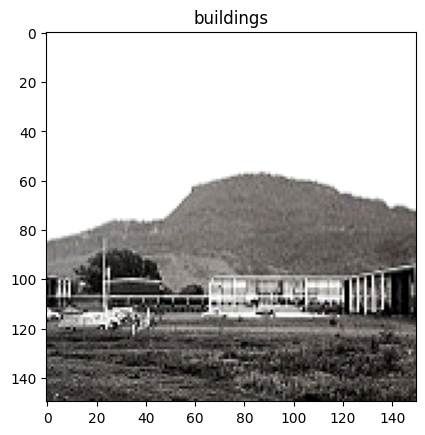

In [4]:
image,label=train_dataset[0]
print("shape=",image.shape)
plt.imshow(image.permute(1,2,0))
plt.title(train_dataset.classes[label])
plt.show()

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Conv2d(3,16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
       
            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head=nn.Sequential(
            nn.Flatten(),
            nn.Linear(9*9*128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,6)
        )
    def forward(self,x):
        x=self.backbone(x)
        x=self.head(x)
        return x

In [6]:
device=torch.device('cuda')
model=CNN()
model=model.to(device)
criteration=nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer=optim.Adam(model.parameters(),lr=0.001)
epochs = 15
for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        pred = model(images)
        loss = criteration(pred, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
        pred_label = torch.argmax(pred, dim=1)
        train_total += labels.size(0)
        train_correct += (pred_label == labels).sum().item()
    avg_train_loss = running_train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            pred = model(images)
            loss = criteration(pred, labels)
            running_val_loss += loss.item()
            pred_label = torch.argmax(pred, dim=1)
            val_total += labels.size(0)
            val_correct += (pred_label == labels).sum().item()
    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")




Epoch [1/15] | Train Loss: 1.3277 | Train Acc: 55.77% | Val Loss: 1.0721 | Val Acc: 68.52%
Epoch [2/15] | Train Loss: 1.0674 | Train Acc: 70.01% | Val Loss: 0.9309 | Val Acc: 76.71%
Epoch [3/15] | Train Loss: 0.9949 | Train Acc: 73.91% | Val Loss: 0.8486 | Val Acc: 80.41%
Epoch [4/15] | Train Loss: 0.9514 | Train Acc: 77.02% | Val Loss: 1.1357 | Val Acc: 66.64%
Epoch [5/15] | Train Loss: 0.9317 | Train Acc: 77.90% | Val Loss: 0.8305 | Val Acc: 81.28%
Epoch [6/15] | Train Loss: 0.9120 | Train Acc: 79.09% | Val Loss: 0.8872 | Val Acc: 78.47%
Epoch [7/15] | Train Loss: 0.9051 | Train Acc: 79.21% | Val Loss: 0.8887 | Val Acc: 77.79%
Epoch [8/15] | Train Loss: 0.8792 | Train Acc: 80.65% | Val Loss: 0.7952 | Val Acc: 83.06%
Epoch [9/15] | Train Loss: 0.8665 | Train Acc: 81.46% | Val Loss: 0.7842 | Val Acc: 83.12%
Epoch [10/15] | Train Loss: 0.8546 | Train Acc: 82.04% | Val Loss: 0.9674 | Val Acc: 74.81%
Epoch [11/15] | Train Loss: 0.8415 | Train Acc: 82.20% | Val Loss: 0.7760 | Val Acc: 85.4

test loss: 0.7467212677001953 | accuracy: 86.2%


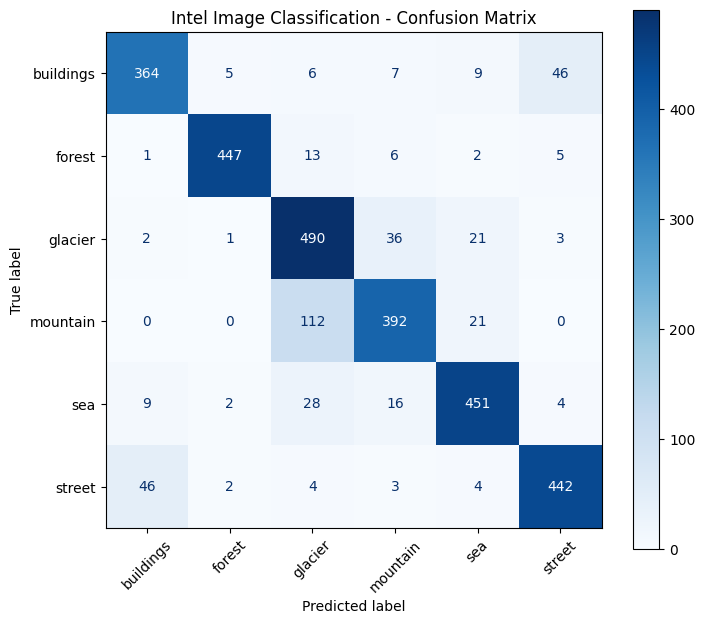

--- Per-Class Accuracy ---
buildings   : 83.30%
forest      : 94.30%
glacier     : 88.61%
mountain    : 74.67%
sea         : 88.43%
street      : 88.22%


In [7]:
model.eval()
with torch.no_grad():
    train_loss=0
    correct=0
    total=0
    all_preds,all_labels=[],[]
    for images, labels in test_loader:
        images,labels=images.to(device), labels.to(device)
        prediction=model(images)
        total+=labels.size(0)
        predicted_class=torch.argmax(prediction, dim=1)
        correct+=(predicted_class==labels).sum().item()
        loss=criteration(prediction, labels)
        train_loss+=loss.item()
        all_preds.extend(predicted_class.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    total_loss=train_loss/len(test_loader)
    accuracy=100*(correct/total)
    print(f"test loss: {total_loss} | accuracy: {accuracy}%")

# 1. Compute Confusion Matrix (y_true first, then y_pred)
cm = confusion_matrix(all_labels, all_preds)
# 2. Display Confusion Matrix with numbers inside
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Intel Image Classification - Confusion Matrix")
plt.show()
# 3. Print Per-Class Accuracy
print("--- Per-Class Accuracy ---")
for i, class_name in enumerate(train_dataset.classes):
    total_class = cm[i].sum()
    correct_class = cm[i, i]
    class_accuracy = 100 * correct_class / total_class if total_class > 0 else 0
    print(f"{class_name:<12}: {class_accuracy:.2f}%")

In [8]:
img=read_image('./image.png')

ts=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ConvertImageDtype(torch.float)
])
img=ts(img).to(device).unsqueeze(0)
pred=model(img)
predclass=torch.argmax(pred, dim=1)
classes=train_dataset.classes
print(classes[predclass])

RuntimeError: [Errno 2] No such file or directory: './image.png'